# Student Performance Analysis
This project analyzes the factors associated with student exam performance and compares two regression models for predicting `Exam_Score`.

## 1. Import libraries and load the CSV
The analysis uses pandas for data preparation, seaborn and matplotlib for charts, and scikit-learn for preprocessing and modeling.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

DATA_PATH = Path('StudentPerformanceFactors.csv')
IMAGE_DIR = Path('report_images')
IMAGE_DIR.mkdir(exist_ok=True)
df = pd.read_csv(DATA_PATH)
print(f'Loaded {DATA_PATH.name}: {df.shape[0]:,} rows and {df.shape[1]} columns')
display(df.head())

Loaded StudentPerformanceFactors.csv: 6,607 rows and 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Inspect the data
These checks establish the dataset shape, data types, missing-value profile, and numerical summary statistics before cleaning.

In [2]:
print('Shape:', df.shape)
print('\nData types:')
display(df.dtypes.rename('dtype').to_frame())
print('\nMissing values:')
display(df.isna().sum().rename('missing_count').to_frame())
print('\nSummary statistics:')
display(df.describe(include='all').T)

Shape: (6607, 20)

Data types:


,dtype
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64



Missing values:


,missing_count
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


## 3. Clean the data
Text values are stripped of accidental whitespace, blank strings are treated as missing, numeric columns use the median for imputation, and categorical columns use the most frequent category. This also standardizes category formatting without inventing new labels.

In [3]:
clean_df = df.copy()
text_columns = clean_df.select_dtypes(include='object').columns
for column in text_columns:
    clean_df[column] = clean_df[column].str.strip().replace('', np.nan)

numeric_columns = clean_df.select_dtypes(include=np.number).columns
categorical_columns = clean_df.select_dtypes(include='object').columns
for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())
for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].mode()[0])

print('Missing values after cleaning:', int(clean_df.isna().sum().sum()))
print('Category levels after standardization:')
for column in categorical_columns:
    print(f'{column}: {sorted(clean_df[column].unique())}')

Missing values after cleaning: 0
Category levels after standardization:
Parental_Involvement: ['High', 'Low', 'Medium']
Access_to_Resources: ['High', 'Low', 'Medium']
Extracurricular_Activities: ['No', 'Yes']
Motivation_Level: ['High', 'Low', 'Medium']
Internet_Access: ['No', 'Yes']
Family_Income: ['High', 'Low', 'Medium']
Teacher_Quality: ['High', 'Low', 'Medium']
School_Type: ['Private', 'Public']
Peer_Influence: ['Negative', 'Neutral', 'Positive']
Learning_Disabilities: ['No', 'Yes']
Parental_Education_Level: ['College', 'High School', 'Postgraduate']
Distance_from_Home: ['Far', 'Moderate', 'Near']
Gender: ['Female', 'Male']


## 4. Exploratory Data Analysis
The following six labeled visualizations examine the target distribution, numeric relationships, group differences, and school-type averages. Each figure is saved as a PNG in `report_images` for reuse in the Word report.

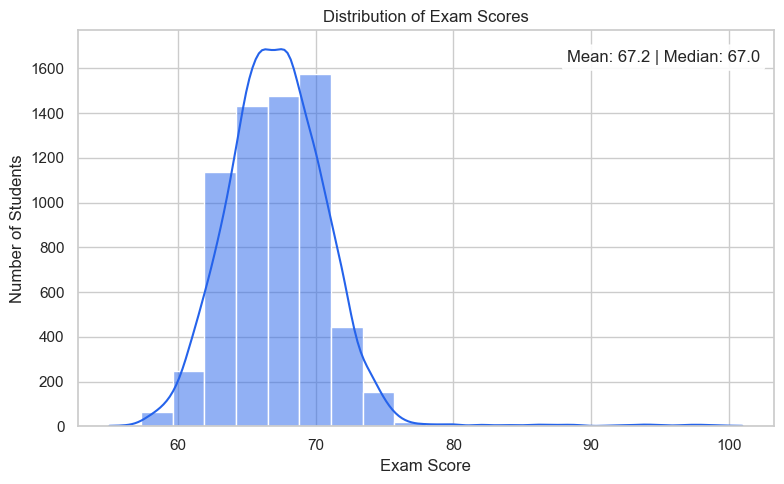

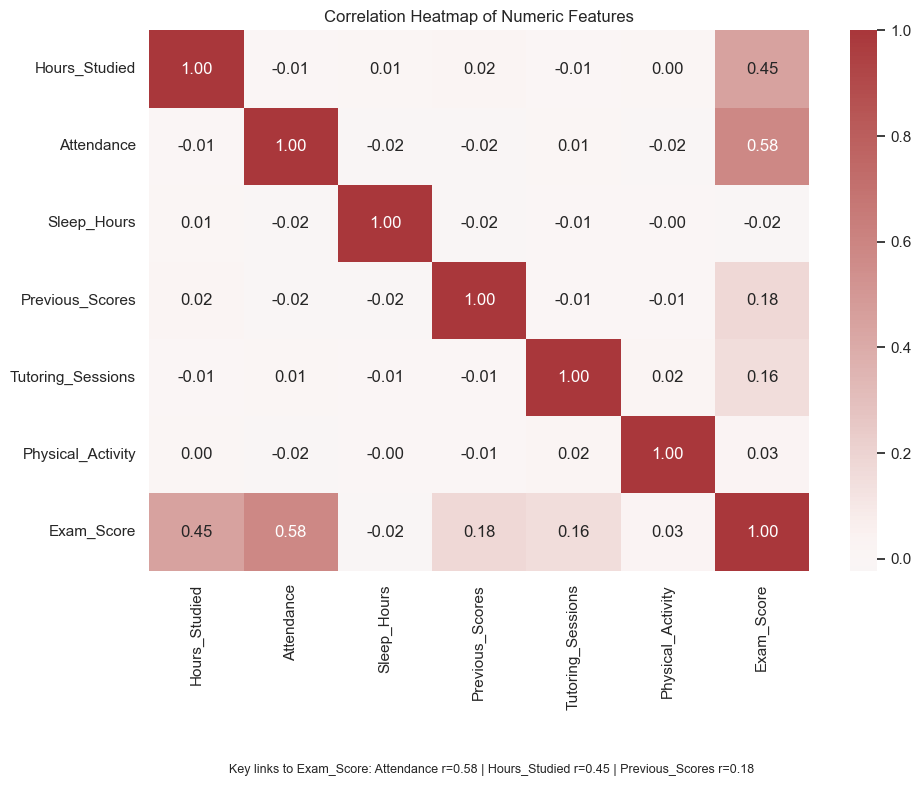

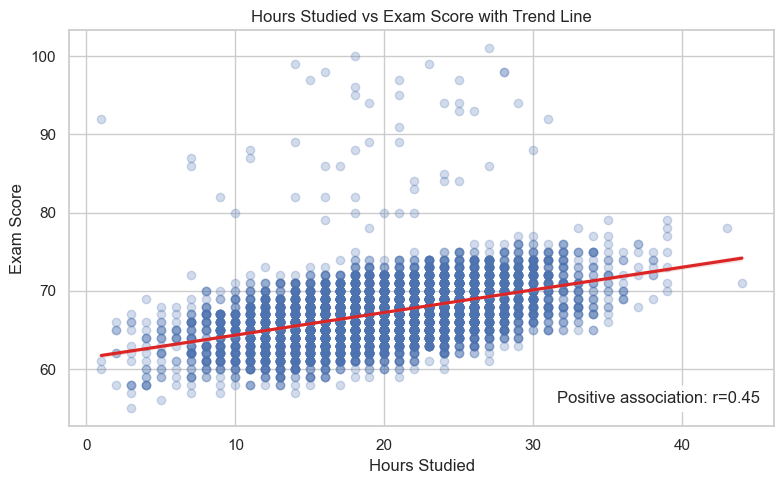

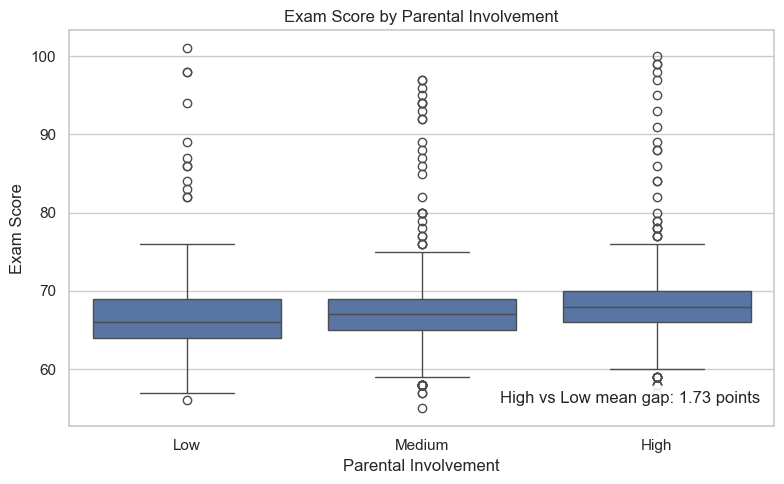

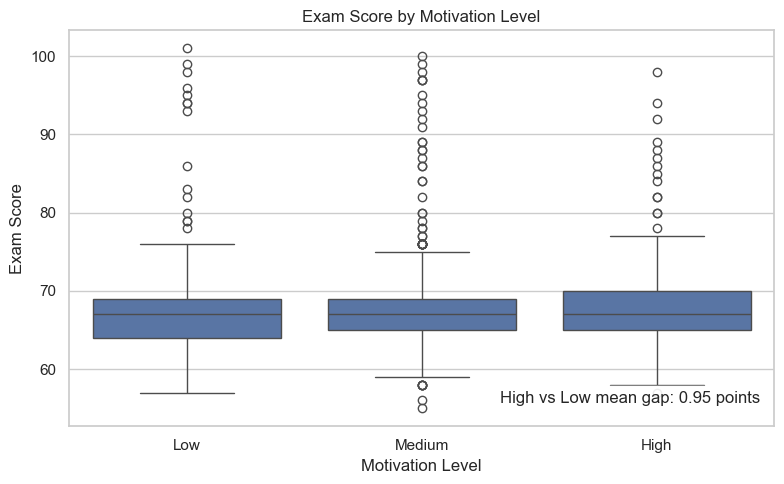

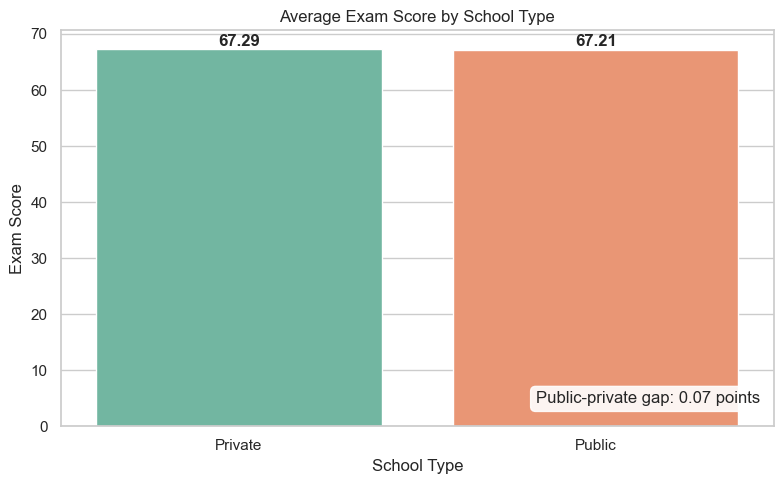

Saved 6 annotated charts to report_images/


In [4]:
sns.set_theme(style='whitegrid', palette='deep')

score_mean = clean_df['Exam_Score'].mean()
score_median = clean_df['Exam_Score'].median()
attendance_corr = clean_df['Attendance'].corr(clean_df['Exam_Score'])
hours_corr = clean_df['Hours_Studied'].corr(clean_df['Exam_Score'])
previous_corr = clean_df['Previous_Scores'].corr(clean_df['Exam_Score'])
parental_average = clean_df.groupby('Parental_Involvement')['Exam_Score'].mean()
motivation_average = clean_df.groupby('Motivation_Level')['Exam_Score'].mean()
school_average = clean_df.groupby('School_Type', as_index=False)['Exam_Score'].mean().sort_values('Exam_Score', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(clean_df['Exam_Score'], bins=20, kde=True, ax=ax, color='#2563eb')
ax.set_title('Distribution of Exam Scores')
ax.set_xlabel('Exam Score')
ax.set_ylabel('Number of Students')
ax.text(0.98, 0.95, f'Mean: {score_mean:.1f} | Median: {score_median:.1f}', transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
fig.tight_layout(); fig.savefig(IMAGE_DIR / '01_exam_score_distribution.png', dpi=200); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 8))
corr = clean_df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features')
fig.text(0.5, 0.02, f'Key links to Exam_Score: Attendance r={attendance_corr:.2f} | Hours_Studied r={hours_corr:.2f} | Previous_Scores r={previous_corr:.2f}', ha='center', va='bottom', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
fig.tight_layout(rect=[0, 0.08, 1, 1]); fig.savefig(IMAGE_DIR / '02_numeric_correlation_heatmap.png', dpi=200, bbox_inches='tight'); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=clean_df, x='Hours_Studied', y='Exam_Score', scatter_kws={'alpha': 0.25}, line_kws={'color': '#dc2626'}, ax=ax)
ax.set_title('Hours Studied vs Exam Score with Trend Line')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
ax.text(0.98, 0.05, f'Positive association: r={hours_corr:.2f}', transform=ax.transAxes, ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
fig.tight_layout(); fig.savefig(IMAGE_DIR / '03_hours_studied_vs_exam_score.png', dpi=200); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=clean_df, x='Parental_Involvement', y='Exam_Score', order=['Low', 'Medium', 'High'], ax=ax)
ax.set_title('Exam Score by Parental Involvement')
ax.set_xlabel('Parental Involvement')
ax.set_ylabel('Exam Score')
ax.text(0.98, 0.05, f'High vs Low mean gap: {parental_average["High"] - parental_average["Low"]:.2f} points', transform=ax.transAxes, ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
fig.tight_layout(); fig.savefig(IMAGE_DIR / '04_exam_score_by_parental_involvement.png', dpi=200); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=clean_df, x='Motivation_Level', y='Exam_Score', order=['Low', 'Medium', 'High'], ax=ax)
ax.set_title('Exam Score by Motivation Level')
ax.set_xlabel('Motivation Level')
ax.set_ylabel('Exam Score')
ax.text(0.98, 0.05, f'High vs Low mean gap: {motivation_average["High"] - motivation_average["Low"]:.2f} points', transform=ax.transAxes, ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
fig.tight_layout(); fig.savefig(IMAGE_DIR / '05_exam_score_by_motivation_level.png', dpi=200); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=school_average, x='School_Type', y='Exam_Score', hue='School_Type', legend=False, ax=ax, palette='Set2')
ax.set_title('Average Exam Score by School Type')
ax.set_xlabel('School Type')
ax.set_ylabel('Exam Score')
for index, row in school_average.reset_index(drop=True).iterrows():
    ax.text(index, row['Exam_Score'] + 0.05, f"{row['Exam_Score']:.2f}", ha='center', va='bottom', fontweight='bold')
ax.text(0.98, 0.05, f'Public-private gap: {abs(school_average.iloc[0]["Exam_Score"] - school_average.iloc[1]["Exam_Score"]):.2f} points', transform=ax.transAxes, ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
fig.tight_layout(); fig.savefig(IMAGE_DIR / '06_average_exam_score_by_school_type.png', dpi=200); plt.show(); plt.close(fig)

print(f'Saved {len(list(IMAGE_DIR.glob("*.png")))} annotated charts to {IMAGE_DIR}/')

## 4. Exploratory Data Analysis
The following six labeled visualizations examine the target distribution, numeric relationships, group differences, and school-type averages. Each figure is saved as a PNG in `report_images` for reuse in the Word report. `Exam_Score` reaches a maximum of 101 even though scores are presumably out of 100; this minor source-data quirk is kept as-is rather than silently altered.

In [5]:
X = clean_df.drop(columns='Exam_Score')
y = clean_df['Exam_Score']
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
ordinal_categories = {
    'Parental_Involvement': ['Low', 'Medium', 'High'],
    'Access_to_Resources': ['Low', 'Medium', 'High'],
    'Motivation_Level': ['Low', 'Medium', 'High'],
    'Family_Income': ['Low', 'Medium', 'High'],
    'Teacher_Quality': ['Low', 'Medium', 'High'],
    'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home': ['Near', 'Moderate', 'Far']
}
ordinal_features = list(ordinal_categories)
nominal_features = [
    column for column in X.select_dtypes(include='object').columns
    if column not in ordinal_features
]
preprocessor = ColumnTransformer([
    ('numeric', SimpleImputer(strategy='median'), numeric_features),
    ('ordinal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=[ordinal_categories[column] for column in ordinal_features],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ]), ordinal_features),
    ('nominal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), nominal_features)
])
print(f'Numeric predictors: {len(numeric_features)}; ordinal predictors: {len(ordinal_features)}; nominal predictors: {len(nominal_features)}')

Numeric predictors: 6; ordinal predictors: 8; nominal predictors: 5


## 6. Split the data into training and test sets
An 80/20 split with a fixed random seed makes the comparison reproducible while reserving unseen data for evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f'Training rows: {len(X_train):,}; test rows: {len(X_test):,}')

Training rows: 5,285; test rows: 1,322


## 7. Train two models
A Linear Regression model provides an interpretable baseline. A Random Forest Regressor captures nonlinear relationships and interactions among the factors.

In [7]:
models = {
    'Linear Regression': Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))])
}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
print('Models trained:', ', '.join(models))

Models trained: Linear Regression, Random Forest


## 8. Evaluate the models
R² measures explained variance, MAE gives the average absolute score error, and RMSE gives extra weight to larger errors. Lower MAE and RMSE are better; higher R² is better.

In [8]:
results = []
for name, prediction in predictions.items():
    results.append({
        'Model': name,
        'R²': r2_score(y_test, prediction),
        'MAE': mean_absolute_error(y_test, prediction),
        'RMSE': mean_squared_error(y_test, prediction) ** 0.5
    })
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
display(results_df.style.format({'R²': '{:.3f}', 'MAE': '{:.3f}', 'RMSE': '{:.3f}'}))

,Model,R²,MAE,RMSE
0,Linear Regression,0.771,0.444,1.799
1,Random Forest,0.673,1.068,2.151


## 9. Conclusion
The three factors most strongly linked to higher exam scores in this dataset are **Attendance**, **Hours_Studied**, and **Previous_Scores**. Attendance has the strongest numeric association, followed by study time and prior achievement. These relationships are associations rather than proof of causation, but they suggest that consistent attendance, dedicated study time, and strong prior learning are useful areas for student-support interventions.

Linear Regression outperformed Random Forest, with higher R² and lower MAE and RMSE. This suggests the relationships between these factors and `Exam_Score` are mostly linear/additive rather than needing the added complexity Random Forest offers.